## Prompt: "Can you write Python code that calculate how how far a ball will fly if its initial velocity is V and the initial angle is A. Use Newton's equation to perform the calculation."

In [ ]:
import math

def calculate_range(V, A):
    # Convert angle A from degrees to radians
    A_rad = math.radians(A)

    # Acceleration due to gravity (in m/s^2)
    g = 9.81

    # Calculate the range R
    R = (V**2 * math.sin(2 * A_rad)) / g

    return R

# Example usage
initial_velocity = 50  # in meters per second
launch_angle = 45      # in degrees

range_distance = calculate_range(initial_velocity, launch_angle)
print(f"The ball will fly approximately {range_distance:.2f} meters.")


The ball will fly approximately 254.84 meters.


## Prompt: "Can you also create the python code for the same problem but this time include the influence of air drag. The ball is spherical with a diameter D."

In [ ]:
import math
import numpy as np
from scipy.integrate import solve_ivp

def equations_of_motion(t, y, params):
    Vx, Vy = y[2], y[3]
    v = math.sqrt(Vx**2 + Vy**2)
    g, rho, Cd, A, m = params

    # Drag forces
    Fd_x = -0.5 * Cd * rho * A * Vx * v
    Fd_y = -0.5 * Cd * rho * A * Vy * v

    # Equations of motion
    dVx_dt = Fd_x / m
    dVy_dt = (Fd_y / m) - g

    return [Vx, Vy, dVx_dt, dVy_dt]

def calculate_trajectory(V, A, D, m):
    g = 9.81  # Gravity in m/s^2
    rho = 1.225  # Air density in kg/m^3
    Cd = 0.47  # Drag coefficient for a sphere
    A = math.pi * (D / 2)**2  # Cross-sectional area in m^2

    # Initial conditions
    A_rad = math.radians(A)
    Vx0 = V * math.cos(A_rad)
    Vy0 = V * math.sin(A_rad)
    y0 = [0, 0, Vx0, Vy0]  # Initial positions and velocities

    # Parameters tuple
    params = (g, rho, Cd, A, m)

    # Time span for the simulation
    t_span = (0, 10)  # Assume the ball will land within 10 seconds
    t_eval = np.linspace(0, 10, 1000)  # Evaluation times

    # Solve the differential equations
    sol = solve_ivp(equations_of_motion, t_span, y0, args=(params,), t_eval=t_eval, rtol=1e-8, atol=1e-8)

    # Extract positions
    x = sol.y[0]
    y = sol.y[1]

    # Find where the ball hits the ground (y=0)
    ground_hits = np.where(y <= 0)[0]
    if len(ground_hits) > 0:
        range_distance = x[ground_hits[0]]
    else:
        range_distance = x[-1]  # If it never hits the ground in the interval, take the last position

    return range_distance

# Example usage
initial_velocity = 50  # in meters per second
launch_angle = 45      # in degrees
diameter = 0.1         # in meters
mass = 0.145           # in kilograms (typical mass of a baseball)

range_distance = calculate_trajectory(initial_velocity, launch_angle, diameter, mass)
print(f"The ball will fly approximately {range_distance:.2f} meters.")


The ball will fly approximately 0.00 meters.


#### JB: let's try to fix the provided Python code.

In [ ]:
import math
import numpy as np
from scipy.integrate import solve_ivp

def equations_of_motion(t, y, params):
    Vx, Vy = y[2], y[3]
    v = math.sqrt(Vx**2 + Vy**2)
    g, rho, Cd, A, m = params

    # Drag forces
    Fd_x = -0.5 * Cd * rho * A * Vx * v
    Fd_y = -0.5 * Cd * rho * A * Vy * v

    # Equations of motion
    dVx_dt = Fd_x / m
    dVy_dt = (Fd_y / m) - g

    return [Vx, Vy, dVx_dt, dVy_dt]

## JB: the argument "A" was overwritten by the ball area-------------------------------------
def calculate_trajectory(V, Adeg, D, m):
    g = 9.81  # Gravity in m/s^2
    rho = 1.225  # Air density in kg/m^3
    Cd = 0.47  # Drag coefficient for a sphere
    Cd = 0.45
    A = math.pi * (D / 2)**2  # Cross-sectional area in m^2

    # Initial conditions
    A_rad = math.radians(Adeg)
    Vx0 = V * math.cos(A_rad)
    Vy0 = V * math.sin(A_rad)
    y0 = [0, 0, Vx0, Vy0]  # Initial positions and velocities

    # Parameters tuple
    params = (g, rho, Cd, A, m)

    # Time span for the simulation
    t_span = (0, 10)  # Assume the ball will land within 10 seconds
    t_eval = np.linspace(0, 10, 1000)  # Evaluation times

    # Solve the differential equations
    sol = solve_ivp(equations_of_motion, t_span, y0, args=(params,), t_eval=t_eval, rtol=1e-8, atol=1e-8)

    # Extract positions
    x = sol.y[0,1:] ## JB: needed to remove the first row------------------------------------
    y = sol.y[1,1:] ## JB: needed to remove the first row------------------------------------

    # Find where the ball hits the ground (y=0)
    ground_hits = np.where(y <= 0)[0]
    if len(ground_hits) > 0:
        range_distance = x[ground_hits[0]]
    else:
        range_distance = x[-1]  # If it never hits the ground in the interval, take the last position

    return range_distance

# Example usage
initial_velocity = 28  # in meters per second
launch_angle = 44      # in degrees
diameter = 0.12273     # in meters
mass = 7.26            # in kilograms (typical mass of a baseball)

range_distance = calculate_trajectory(initial_velocity, launch_angle, diameter, mass)
print(f"The ball will fly approximately {range_distance:.2f} meters.")


The ball will fly approximately 77.86 meters.


## ChatGPT Data Analysis

I am interested in predicting the distance as a function of the angle and velocity. What regression model do you recommend that I use? Can you provide python code for the analysis?

Angle       0
Velocity    0
Distance    0
dtype: int64
Mean Squared Error: 665.0281933641038
R-squared: 0.8026264556033835


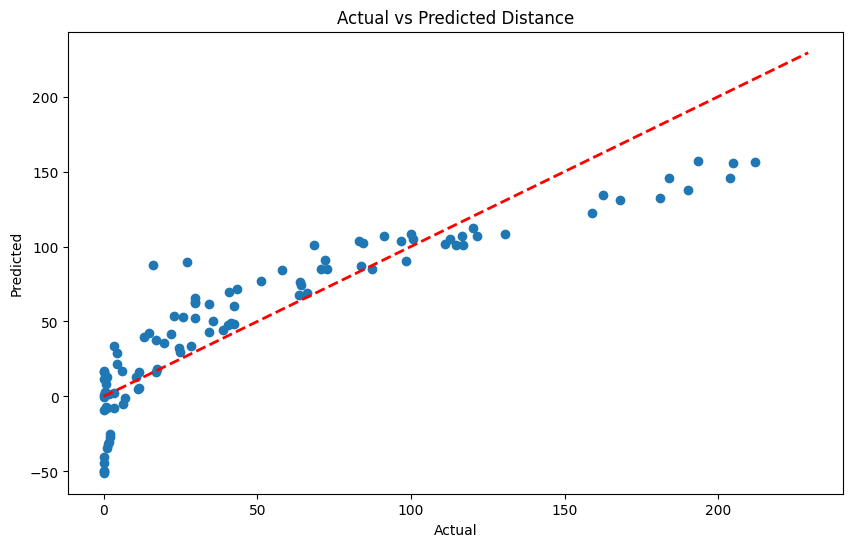

          Coefficient
Angle        1.916470
Velocity     3.127671


In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (assuming the data is saved in a CSV file named 'data.csv')
data = pd.read_csv('data_XY.csv', header=None, names=['Angle', 'Velocity', 'Distance'])

# Check for missing values
print(data.isnull().sum())

# Split the data into features (X) and target (y)
X = data[['Angle', 'Velocity']]
y = data['Distance']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Distance')
plt.show()

# Display the coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)


Can you also provide the python code a polynomial regression model?

Angle       0
Velocity    0
Distance    0
dtype: int64
Polynomial Regression Mean Squared Error: 1.8599506725272092
Polynomial Regression R-squared: 0.99944798572406


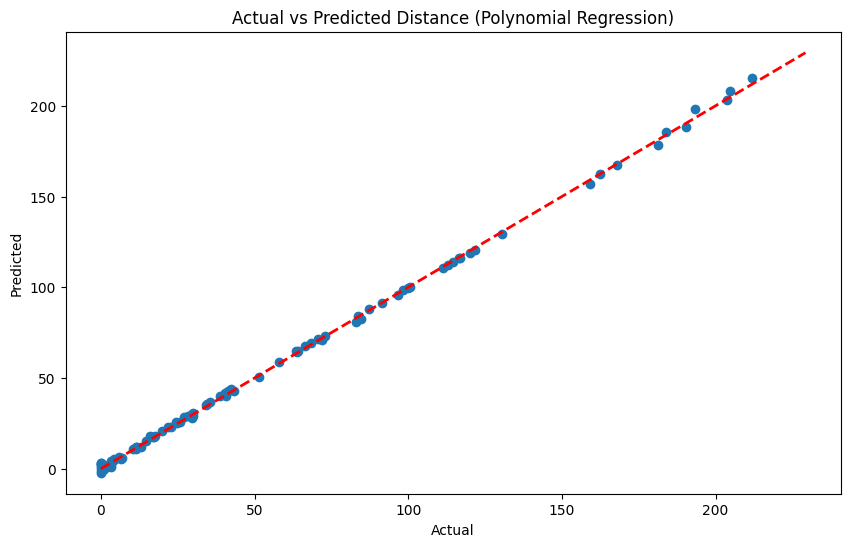

                  Coefficient
1                    0.000000
Angle               -1.158213
Velocity            -0.916213
Angle^2              0.036864
Angle Velocity       0.102839
Velocity^2           0.022303
Angle^3             -0.000293
Angle^2 Velocity    -0.002103
Angle Velocity^2     0.002029
Velocity^3          -0.000128


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the data (assuming the data is saved in a CSV file named 'data.csv')
data = pd.read_csv('data_XY.csv', header=None, names=['Angle', 'Velocity', 'Distance'])

# Check for missing values
print(data.isnull().sum())

# Split the data into features (X) and target (y)
X = data[['Angle', 'Velocity']]
y = data['Distance']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transform features to polynomial features
degree = 3  # You can change the degree to fit your needs
poly = PolynomialFeatures(degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Initialize and train the polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

# Make predictions on the test set
y_poly_pred = poly_model.predict(X_poly_test)

# Evaluate the model
poly_mse = mean_squared_error(y_test, y_poly_pred)
poly_r2 = r2_score(y_test, y_poly_pred)
print(f'Polynomial Regression Mean Squared Error: {poly_mse}')
print(f'Polynomial Regression R-squared: {poly_r2}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_poly_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Distance (Polynomial Regression)')
plt.show()

# Display the coefficients
coefficients = pd.DataFrame(poly_model.coef_, poly.get_feature_names_out(X.columns), columns=['Coefficient'])
print(coefficients)

Can you also provide the Python code for a random forest analysis?

Angle       0
Velocity    0
Distance    0
dtype: int64
Random Forest Regression Mean Squared Error: 15.80296865727546
Random Forest Regression R-squared: 0.9953098410458406


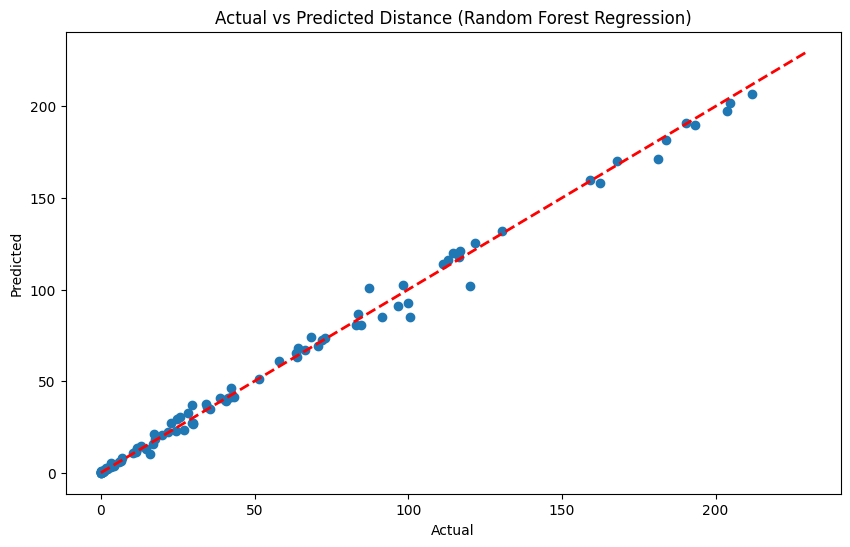

          Importance
Angle       0.308681
Velocity    0.691319


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the data (assuming the data is saved in a CSV file named 'data.csv')
data = pd.read_csv('data_XY.csv', header=None, names=['Angle', 'Velocity', 'Distance'])

# Check for missing values
print(data.isnull().sum())

# Split the data into features (X) and target (y)
X = data[['Angle', 'Velocity']]
y = data['Distance']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_rf_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test, y_rf_pred)
print(f'Random Forest Regression Mean Squared Error: {rf_mse}')
print(f'Random Forest Regression R-squared: {rf_r2}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_rf_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Distance (Random Forest Regression)')
plt.show()

# Feature importances
feature_importances = pd.DataFrame(rf_model.feature_importances_, index=X.columns, columns=['Importance'])
print(feature_importances)

### Can you write Python code that calculate how how far a ball will fly if its initial velocity is V and the initial angle is A. Use Newton's equation to perform the calculation and include the influence of air drag.

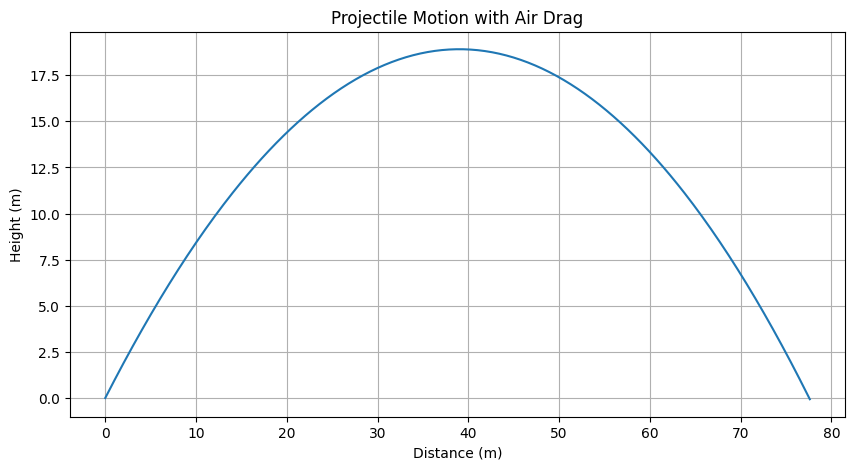

The ball will fly approximately 77.61 meters.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
g = 9.81  # Acceleration due to gravity (m/s^2)
rho = 1.204  # Density of air (kg/m^3)
Cd = 0.45  # Drag coefficient of a sphere
r = 0.061366  # Radius of the ball (m)
A = np.pi * r**2  # Cross-sectional area (m^2)
m = 7.26  # Mass of the ball (kg)

# Function to compute the drag force
def drag_force(v):
    return 0.5 * Cd * A * rho * v**2

# Function to perform the projectile motion calculation with air drag
def calculate_trajectory(V, angle, dt=0.01):
    # Initial conditions
    theta = np.radians(angle)
    vx = V * np.cos(theta)
    vy = V * np.sin(theta)
    x, y = 0.0, 0.0

    # Lists to store trajectory points
    x_points = [x]
    y_points = [y]

    # Time loop
    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)
        Fd = drag_force(v)
        ax = -Fd * vx / (m * v)
        ay = -g - (Fd * vy / (m * v))

        # Update velocities
        vx += ax * dt
        vy += ay * dt

        # Update positions
        x += vx * dt
        y += vy * dt

        # Store trajectory points
        x_points.append(x)
        y_points.append(y)

    return x_points, y_points

# Initial conditions
initial_velocity = 28.0  # Initial velocity in m/s
initial_angle = 44.0  # Initial angle in degrees

# Calculate the trajectory
x_points, y_points = calculate_trajectory(initial_velocity, initial_angle)

# Plot the trajectory
plt.figure(figsize=(10, 5))
plt.plot(x_points, y_points)
plt.xlabel('Distance (m)')
plt.ylabel('Height (m)')
plt.title('Projectile Motion with Air Drag')
plt.grid(True)
plt.show()

# Print the range of the projectile
print(f'The ball will fly approximately {x_points[-1]:.2f} meters.')
